# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [6]:
dir = "./../../data/"
data_file = dir + "uvtable_nonsym_disc_blob.npz"
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1*2

# Load data
file = np.load(data_file)
u, v, Vis, Weights = file['u'], file['v'], file['vis'], file['weights']
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)

## frank2d

In [7]:
N = 300

In [8]:
frank2d = Frank2D(N, rout, geom)

In [9]:
frank2d.process_vis(uvtable)

===>  Setting gridded data...


In [10]:
uvtable_gridded = frank2d.gridded_data

In [11]:
u_syn = uvtable_gridded['u'].reshape(N, N)
v_syn = uvtable_gridded['v'].reshape(N, N)
vis_syn = uvtable_gridded['vis'].reshape(N, N)
weights_syn = uvtable_gridded['weights'].reshape(N, N)

Text(0, 0.5, 'v [λ]')

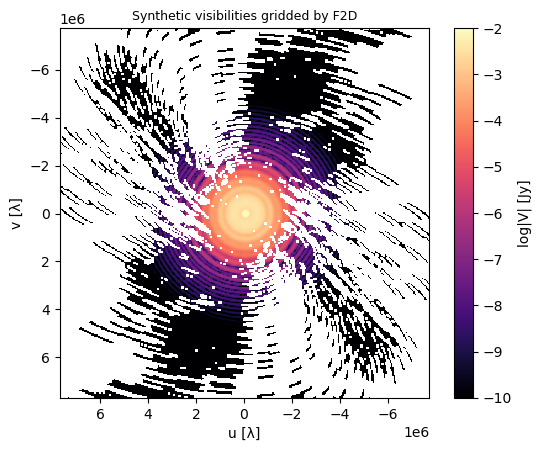

In [12]:
plt.imshow(np.log(np.abs(vis_syn)),
             extent=[u_syn.max(), u_syn.min(), v_syn.max(), v_syn.min()], 
             cmap = "magma", 
             vmin=-10, vmax=-2)
plt.colorbar(label='log|V| [Jy]')
plt.title('Synthetic visibilities gridded by F2D', size=9)
plt.xlabel('u [λ]')
plt.ylabel('v [λ]')

In [32]:
params_1 = {'m' : -2, 'c' : 1e8, 'l' : 5e4}
params_2 = {'m' : -1.8, 'c' : 1e8, 'l' : 5e4}
params_3 = {'m' : -5, 'c' : 1e25, 'l' : 5e4}
params_4 = {'m' : -2.5, 'c' : 1e9, 'l' : 5e4}
params_5 = {'m' : -1, 'c' : 1e6, 'l' : 5e4}
best_N50 = {'m': -2.0101026116553413, 'c': 24804356714.379826, 'l': 61468.461366034964}

In [33]:
params = [params_1, params_2, params_3, params_4, params_5, best_N50]

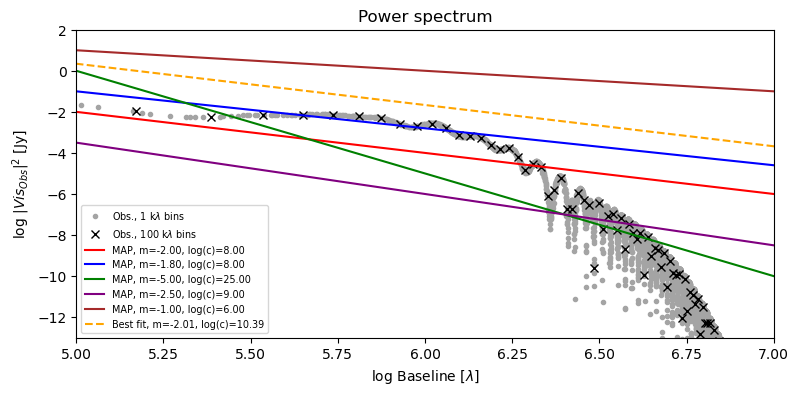

In [34]:
# Plot visibilities gridded.
from frank.utilities import UVDataBinner       
bin_widths=[1e3, 1e5]

u, v = u_syn.flatten(), v_syn.flatten()
Vis = vis_syn.flatten()
Weights = weights_syn.flatten()

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
logx = np.log10(binned_vis.uv)
logy = np.log10(np.abs(binned_vis.V)**2)

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
logx2 = np.log10(binned_vis2.uv)
logy2 = np.log10(np.abs(binned_vis2.V)**2)

def linear_power_spectrum(logx, m, c):
    return m*logx + np.log10(c)


lgx = np.log10(np.geomspace(np.sort(baselines)[1], baselines.max(), 1000))

lgy1 = linear_power_spectrum(lgx, params_1['m'], params_1['c'])
lgy2 = linear_power_spectrum(lgx, params_2['m'], params_2['c'])
lgy3 = linear_power_spectrum(lgx, params_3['m'], params_3['c'])
lgy4 = linear_power_spectrum(lgx, params_4['m'], params_4['c'])
lgy5 = linear_power_spectrum(lgx, params_5['m'], params_5['c'])
lgy_best = linear_power_spectrum(lgx, best_N50['m'], best_N50['c'])

cs, ms = ['#a4a4a4', 'k'], ['.', 'x']

plt.figure(figsize=(9, 4))
plt.plot(logx, logy, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

plt.plot(lgx, lgy1, ls='-', color= 'r', label='MAP, m={:.2f}, log(c)={:.2f}'.format(params_1['m'], np.log10(params_1['c'])))
plt.plot(lgx, lgy2, ls='-', color= 'blue', label='MAP, m={:.2f}, log(c)={:.2f}'.format(params_2['m'], np.log10(params_2['c'])))
plt.plot(lgx, lgy3, ls='-', color= 'green', label='MAP, m={:.2f}, log(c)={:.2f}'.format(params_3['m'], np.log10(params_3['c'])))
plt.plot(lgx, lgy4, ls='-', color= 'purple', label='MAP, m={:.2f}, log(c)={:.2f}'.format(params_4['m'], np.log10(params_4['c'])))
plt.plot(lgx, lgy5, ls='-', color= 'brown', label='MAP, m={:.2f}, log(c)={:.2f}'.format(params_5['m'], np.log10(params_5['c'])))
plt.plot(lgx, lgy_best, ls='--', color= 'orange', label='Best fit, m={:.2f}, log(c)={:.2f}'.format(best_N50['m'], np.log10(best_N50['c'])))

plt.xlabel(r'log Baseline [$\lambda$]', size = 10)
plt.ylabel(r'log $|Vis_{Obs}|^{2}$ [Jy]', size = 10)
plt.legend(loc = 'best', fontsize = 'x-small')
plt.title("Power spectrum")
plt.ylim(-13, 2)
plt.xlim(5, 7)
plt.show()

### frank2d for different m and c

In [35]:
geom = Geometry(0, 0, 0, 0)

In [36]:
N = 500

In [37]:
times = []
frank2d_objects = []

===>  Setting gridded data...
===>  Setting GP Kernel Wendland...
     + Kernel parameters:  {'m': -2, 'c': 100000000.0, 'l': 50000.0}
===>  Creating sparse linear system...
    + time kernel = 0.03  min |  1.74 seconds
Using preconditioner method:  jacobi
    + time building system = 0.03  min |  1.78 seconds
===>  Solving linear system...
     + maxiter =  50000  & rtol =  1e-10
         * rtol: 1e-10
         * final tolerance: 0.012212677737961327
     + final tolerance :  0.012212677737961327
                       .... iteration:  0
                        -> actual tol:  122126777.37961327  vs  0.012212677737961327
                       .... iteration:  1
                        -> actual tol:  7481605.6505377805  vs  0.012212677737961327
                       .... iteration:  2
                        -> actual tol:  7617806.845557843  vs  0.012212677737961327
                       .... iteration:  3
                        -> actual tol:  3630691.701392375  vs  0.0122126777

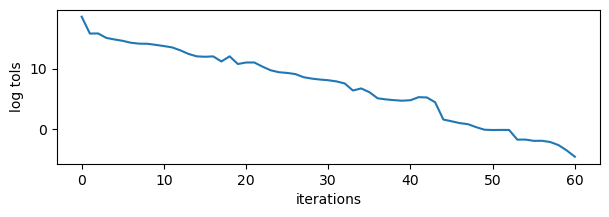

    + time = 0.02  min |  1.07 seconds
     + CGM converged?   True
True
         ✔✔✔✔✔✔✔ CGM Sucess..
     + Fit correctly?   None
Building full visibility model...
--> times building full visibility model = 0.09  min |  5.51 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with params ={'m': -2, 'c': 100000000.0, 'l': 50000.0} took 14.764732599258423 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel Wendland...
     + Kernel parameters:  {'m': -1.8, 'c': 100000000.0, 'l': 50000.0}
===>  Creating sparse linear system...
    + time kernel = 0.03  min |  1.75 seconds
Using preconditioner method:  jacobi
    + time building system = 0.03  min |  1.78 seconds
===>  Solving linear system...
     + maxiter =  50000  & rtol =  1e-10
         * rtol: 1e-10
         * final tolerance: 0.012212677737961327
     + final tolerance :  0.012212677737961327
                       .... iteration:  0
                        -> actual tol:  122126777.37961327  vs  0.012212

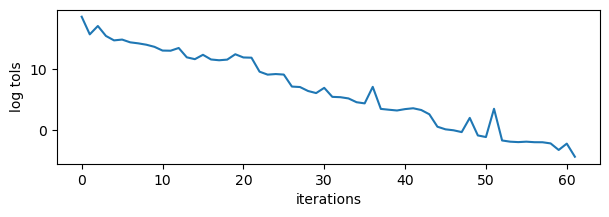

    + time = 0.02  min |  1.09 seconds
     + CGM converged?   True
True
         ✔✔✔✔✔✔✔ CGM Sucess..
     + Fit correctly?   None
Building full visibility model...
--> times building full visibility model = 0.09  min |  5.52 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with params ={'m': -1.8, 'c': 100000000.0, 'l': 50000.0} took 14.791659116744995 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel Wendland...
     + Kernel parameters:  {'m': -5, 'c': 1e+25, 'l': 50000.0}
===>  Creating sparse linear system...
    + time kernel = 0.03  min |  1.76 seconds
Using preconditioner method:  jacobi
    + time building system = 0.03  min |  1.80 seconds
===>  Solving linear system...
     + maxiter =  50000  & rtol =  1e-10
         * rtol: 1e-10
         * final tolerance: 0.012212677737961327
     + final tolerance :  0.012212677737961327
                       .... iteration:  0
                        -> actual tol:  122126777.37961327  vs  0.012212677737

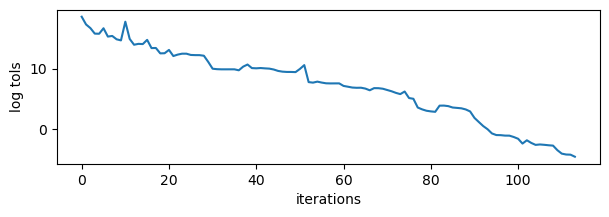

    + time = 0.03  min |  1.89 seconds
     + CGM converged?   True
True
         ✔✔✔✔✔✔✔ CGM Sucess..
     + Fit correctly?   None
Building full visibility model...
--> times building full visibility model = 0.09  min |  5.51 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with params ={'m': -5, 'c': 1e+25, 'l': 50000.0} took 15.605071783065796 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel Wendland...
     + Kernel parameters:  {'m': -2.5, 'c': 1000000000.0, 'l': 50000.0}
===>  Creating sparse linear system...
    + time kernel = 0.03  min |  1.74 seconds
Using preconditioner method:  jacobi
    + time building system = 0.03  min |  1.77 seconds
===>  Solving linear system...
     + maxiter =  50000  & rtol =  1e-10
         * rtol: 1e-10
         * final tolerance: 0.012212677737961327
     + final tolerance :  0.012212677737961327
                       .... iteration:  0
                        -> actual tol:  122126777.37961327  vs  0.01221267773

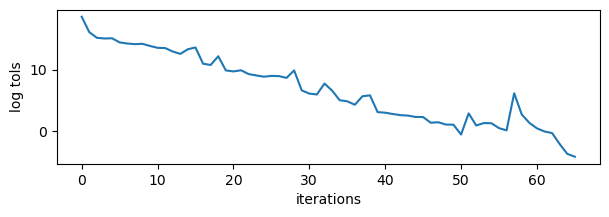

    + time = 0.02  min |  1.13 seconds
     + CGM converged?   True
True
         ✔✔✔✔✔✔✔ CGM Sucess..
     + Fit correctly?   None
Building full visibility model...
--> times building full visibility model = 0.09  min |  5.45 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with params ={'m': -2.5, 'c': 1000000000.0, 'l': 50000.0} took 14.71388840675354 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel Wendland...
     + Kernel parameters:  {'m': -1, 'c': 1000000.0, 'l': 50000.0}
===>  Creating sparse linear system...
    + time kernel = 0.03  min |  1.69 seconds
Using preconditioner method:  jacobi
    + time building system = 0.03  min |  1.73 seconds
===>  Solving linear system...
     + maxiter =  50000  & rtol =  1e-10
         * rtol: 1e-10
         * final tolerance: 0.012212677737961327
     + final tolerance :  0.012212677737961327
                       .... iteration:  0
                        -> actual tol:  122126777.37961327  vs  0.01221267

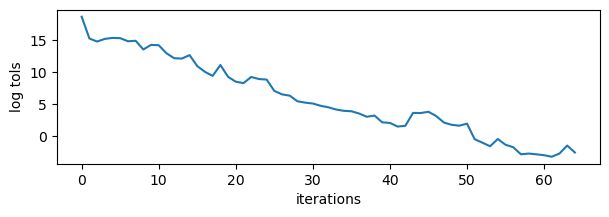

    + time = 0.02  min |  1.12 seconds
     + CGM converged?   True
False
         ✘✘✘✘✘✘ CGM Failed..
     + Fit correctly?   None
Building full visibility model...
--> times building full visibility model = 0.09  min |  5.46 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with params ={'m': -1, 'c': 1000000.0, 'l': 50000.0} took 14.69584846496582 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel Wendland...
     + Kernel parameters:  {'m': -2.0101026116553413, 'c': 24804356714.379826, 'l': 61468.461366034964}
===>  Creating sparse linear system...
    + time kernel = 0.03  min |  2.08 seconds
Using preconditioner method:  jacobi
    + time building system = 0.04  min |  2.14 seconds
===>  Solving linear system...
     + maxiter =  50000  & rtol =  1e-10
         * rtol: 1e-10
         * final tolerance: 0.012212677737961327
     + final tolerance :  0.012212677737961327
                       .... iteration:  0
                        -> actual tol:  12

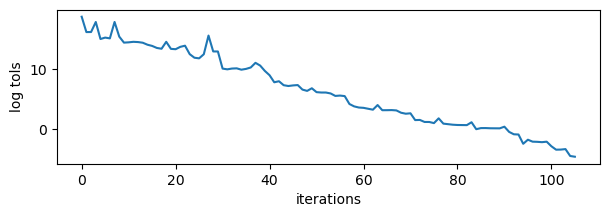

    + time = 0.04  min |  2.62 seconds
     + CGM converged?   True
False
         ✘✘✘✘✘✘ CGM Failed..
     + Fit correctly?   None
Building full visibility model...
--> times building full visibility model = 0.10  min |  6.01 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with params ={'m': -2.0101026116553413, 'c': 24804356714.379826, 'l': 61468.461366034964} took 17.13310694694519 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx


In [38]:
for i in range(len(params)):
    start = time.time()
    frank2d = Frank2D(N, rout, geom)
    frank2d.fit(data = uvtable, kernel_params = params[i], rtol = 1e-10)

    end = time.time()
    total_time = end - start
    times.append(total_time)
    print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with params ={params[i]} took {end - start} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")
    frank2d_objects.append(frank2d)


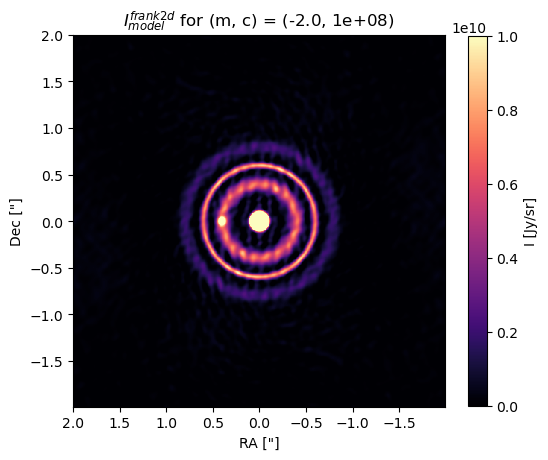

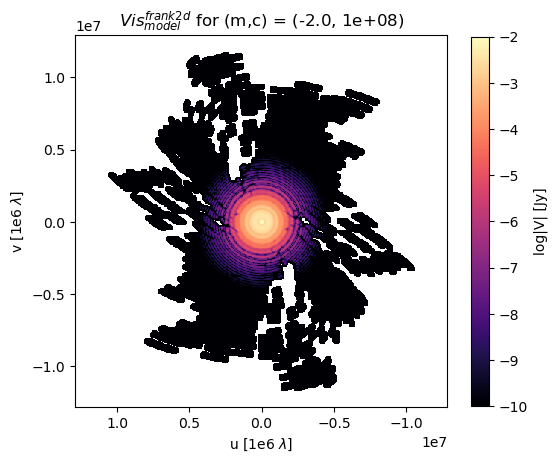

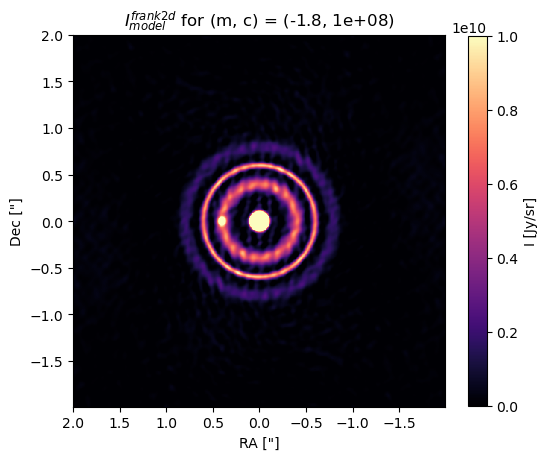

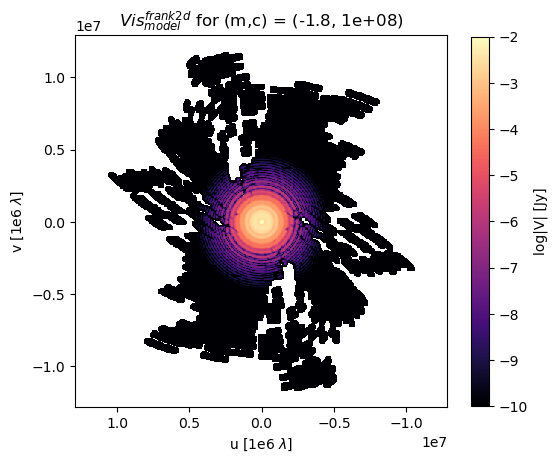

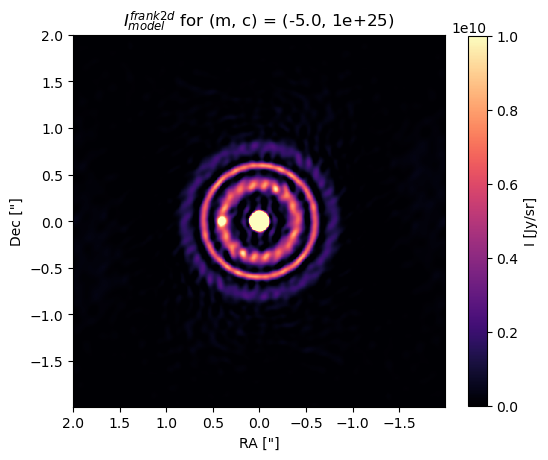

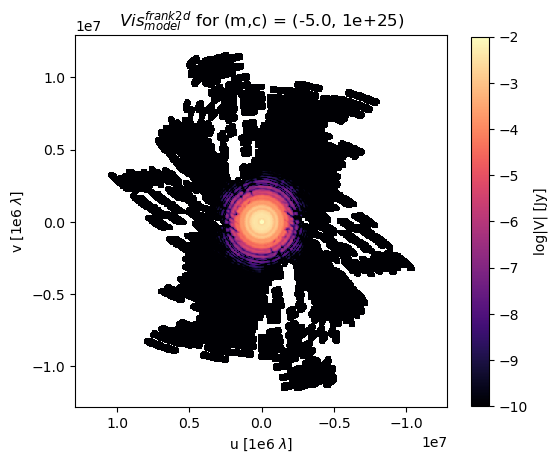

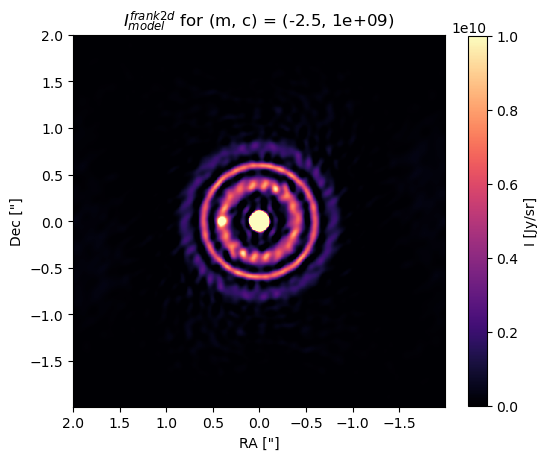

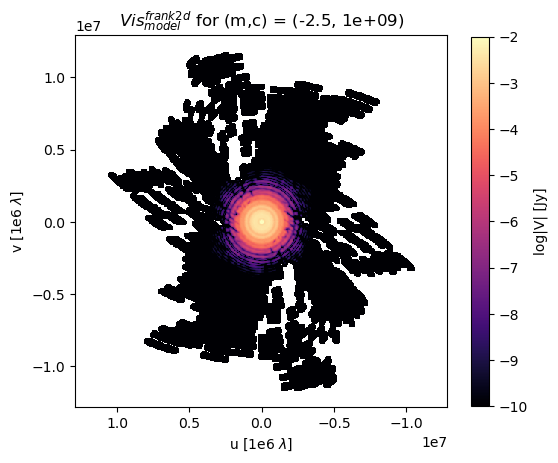

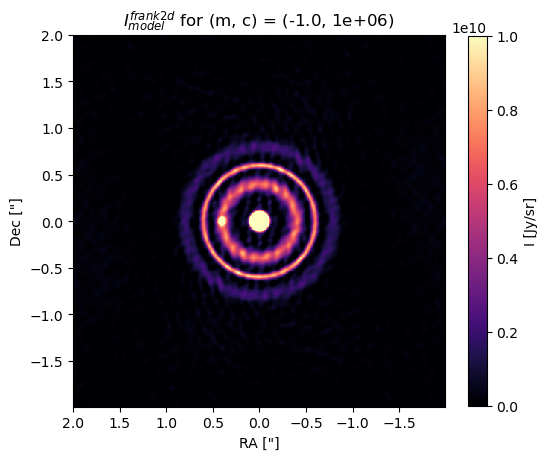

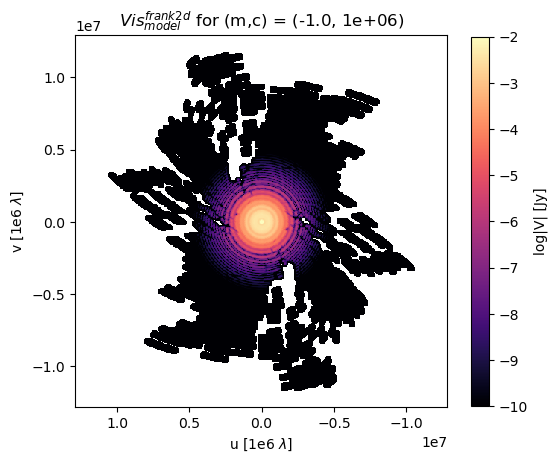

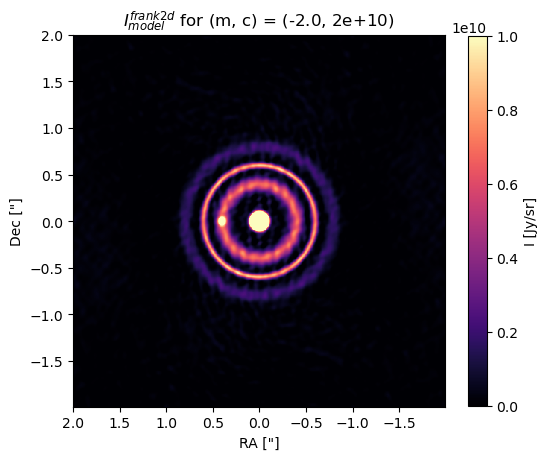

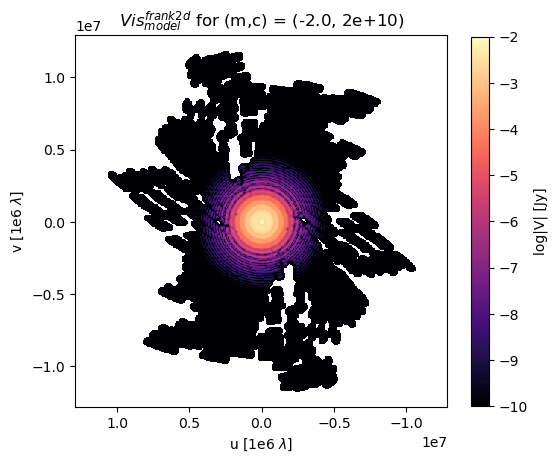

In [43]:
for i in range(len(params)):
    Plot_ = Plot(frank2d_objects[i])
    Plot_.intensity( vmax=1e10,  gamma = 1, zoom=1,
                     title= r'$I_{model}^{frank2d}$ for (m, c) = ('+ f'{params[i]['m']:.1f}' + ', ' + f'{params[i]['c']:.0e}' + ')')
    Plot_.visibility(fig_size = 6,
                     title = r'$Vis_{model}^{frank2d}$ for (m,c) = (' + f'{params[i]['m']:.1f}' + ', ' + f'{params[i]['c']:.0e}'+ ')')

In [ ]:
# Mi idea acá mejor será mostrar como para un misma slope, y diferentes c, los ajustes son diferentes.